In [17]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import re

In [18]:
import re
import matplotlib.pyplot as plt

# Define the path to your log file
log_file_path = 'output.log'

# Initialize a dictionary to store the count of each reaction type
reaction_counts = {
    'f1': 0,
    'f2': 0,
    'f3': 0,
    'f4': 0
}

# Initialize dictionaries to store distances for each type of reaction
reaction_distances = {
    'f1': [],
    'f2': [],
    'f3': [],
    'f4': []
}

# Define a mapping from log reaction types to our reaction types
reaction_map = {
    'reacUM': 'f1',
    'reacMU': 'f2',
    'reacUA': 'f3',
    'reacAU': 'f4'
}

# Open the log file and read its contents
with open(log_file_path, 'r') as file:
    lines = file.readlines()

# Define a regex pattern to match lines containing reacting atom IDs and reaction types
pattern = re.compile(r'reacted_atom_IDs: (reac\w+) (\d+) (\d+)')

# Loop through each line and search for the pattern
for line in lines:
    match = pattern.search(line)
    if match:
        # Extract the reaction type and atom IDs
        reaction_type = match.group(1)
        atom_id_1 = int(match.group(2))
        atom_id_2 = int(match.group(3))
        
        # Calculate distance
        distance = abs(atom_id_1 - atom_id_2)
        
        # Get the corresponding reaction type from the map
        reaction_key = reaction_map[reaction_type]
        
        # Append distance to the appropriate reaction type
        reaction_distances[reaction_key].append(distance)
        
        # Increment the count for the corresponding reaction type
        reaction_counts[reaction_key] += 1

labels = {
    'f1': 'Reaction A to U',
    'f2': 'Reaction M to U',
    'f3': 'Reaction U to A',
    'f4': 'Reaction U to M'
}

# Plot histograms of distances for each reaction type
plt.figure(figsize=(12, 8))
for reaction_type, distances in reaction_distances.items():
    plt.hist(distances, bins=20, alpha=0.7, label=f'{labels[reaction_type]}', density=False)

plt.title('Histogram of Distances for Each Reaction Type')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Print the counts of each reaction type
for reaction_type, count in reaction_counts.items():
    print(f'{labels[reaction_type]} count: {count}')


KeyError: 'reacSwi6toSwi6M'

/home/adrien/.local/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


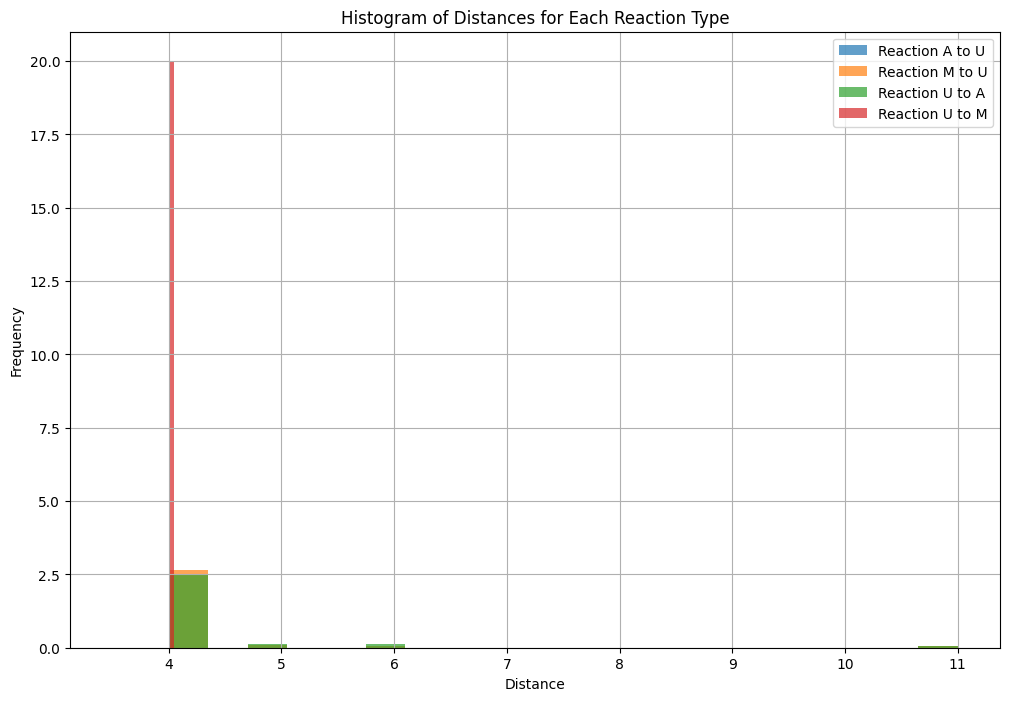

Reaction A to U count: 0
Reaction M to U count: 54
Reaction U to A count: 40
Reaction U to M count: 10
Reaction reacMU between atom IDs 64 and 60 with distance 4
Reaction reacUA between atom IDs 14 and 18 with distance 4
Reaction reacUA between atom IDs 22 and 26 with distance 4
Reaction reacUA between atom IDs 50 and 46 with distance 4
Reaction reacMU between atom IDs 60 and 56 with distance 4
Reaction reacUA between atom IDs 47 and 51 with distance 4
Reaction reacUA between atom IDs 73 and 77 with distance 4
Reaction reacMU between atom IDs 51 and 47 with distance 4
Reaction reacMU between atom IDs 77 and 73 with distance 4
Reaction reacMU between atom IDs 46 and 50 with distance 4
Reaction reacMU between atom IDs 50 and 54 with distance 4
Reaction reacMU between atom IDs 26 and 22 with distance 4
Reaction reacMU between atom IDs 79 and 75 with distance 4
Reaction reacUM between atom IDs 40 and 36 with distance 4
Reaction reacUM between atom IDs 9 and 5 with distance 4
Reaction reacM

In [ ]:
import re
import matplotlib.pyplot as plt

# Define the path to your log file
log_file_path = 'output.log'

# Initialize a dictionary to store the count of each reaction type
reaction_counts = {
    'f1': 0,
    'f2': 0,
    'f3': 0,
    'f4': 0
}

# Initialize dictionaries to store distances for each type of reaction
reaction_distances = {
    'f1': [],
    'f2': [],
    'f3': [],
    'f4': []
}

# Define a mapping from log reaction types to our reaction types
reaction_map = {
    'reacAU': 'f1',
    'reacMU': 'f2',
    'reacUA': 'f3',
    'reacUM': 'f4'
}

# Open the log file and read its contents
with open(log_file_path, 'r') as file:
    lines = file.readlines()

# Define a regex pattern to match lines containing reacting atom IDs and reaction types
pattern = re.compile(r'reacted_atom_IDs: (reac\w+) (\d+) (\d+)')

# List to store reaction data for further use if needed
reaction_data = []

# Loop through each line and search for the pattern
for line in lines:
    match = pattern.search(line)
    if match:
        # Extract the reaction type and atom IDs
        reaction_type = match.group(1)
        atom_id_1 = int(match.group(2))
        atom_id_2 = int(match.group(3))
        
        # Calculate distance
        distance = abs(atom_id_1 - atom_id_2)
        
        # Get the corresponding reaction type from the map
        reaction_key = reaction_map[reaction_type]
        
        # Check if this reaction data already exists
        if (reaction_type, atom_id_1, atom_id_2, distance) not in reaction_data:
            # Append distance to the appropriate reaction type
            reaction_distances[reaction_key].append(distance)
            
            # Increment the count for the corresponding reaction type
            reaction_counts[reaction_key] += 1
    
            # Store the reaction data (including reaction type)
            reaction_data.append((reaction_type, atom_id_1, atom_id_2, distance))


labels = {
    'f1': 'Reaction A to U',
    'f2': 'Reaction M to U',
    'f3': 'Reaction U to A',
    'f4': 'Reaction U to M'
}

# Plot histograms of distances for each reaction type
plt.figure(figsize=(12, 8))
for reaction_type, distances in reaction_distances.items():
    plt.hist(distances, bins=20, alpha=0.7, label=f'{labels[reaction_type]}', density=True)

plt.title('Histogram of Distances for Each Reaction Type')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Print the counts of each reaction type
for reaction_type, count in reaction_counts.items():
    print(f'{labels[reaction_type]} count: {count}')

# Print stored reaction data if needed
for reaction in reaction_data:
    print(f'Reaction {reaction[0]} between atom IDs {reaction[1]} and {reaction[2]} with distance {reaction[3]}')


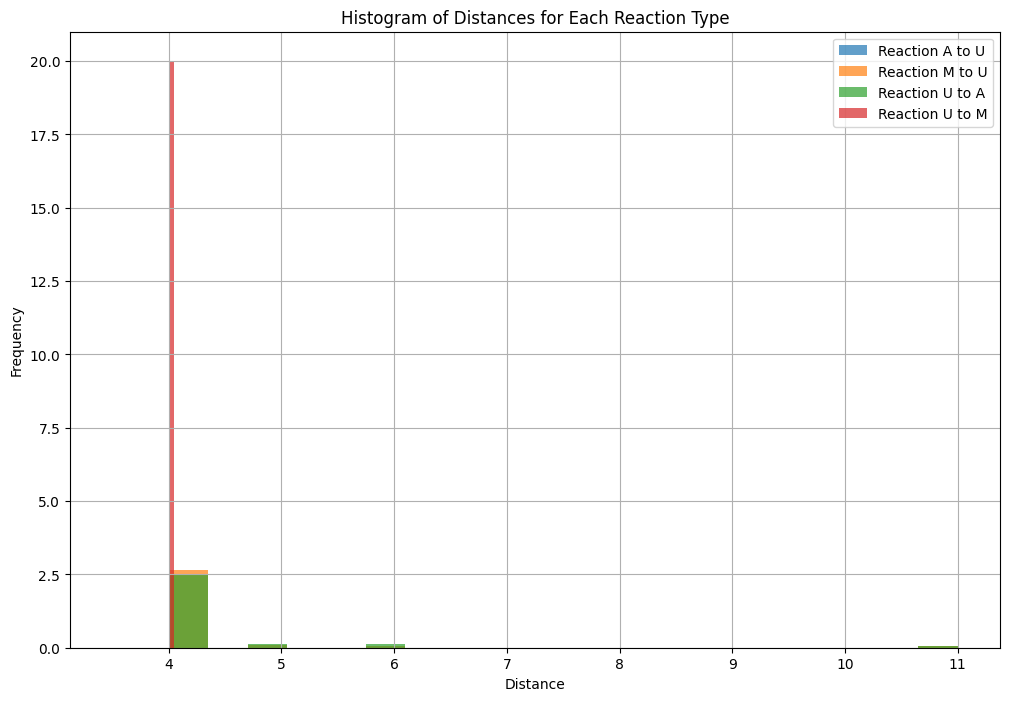

Reaction A to U count: 0
Reaction M to U count: 54
Reaction U to A count: 40
Reaction U to M count: 10


In [ ]:
import re
import matplotlib.pyplot as plt

# Define the path to your log file
log_file_path = 'output.log'

# Initialize dictionaries to store counts and distances for each type of reaction
reaction_counts = {'f1': 0, 'f2': 0, 'f3': 0, 'f4': 0}
reaction_distances = {'f1': set(), 'f2': set(), 'f3': set(), 'f4': set()}

# Define a mapping from log reaction types to our reaction types
reaction_map = {'reacAU': 'f1', 'reacMU': 'f2', 'reacUA': 'f3', 'reacUM': 'f4'}

# Define a regex pattern to match lines containing reacting atom IDs and reaction types
pattern = re.compile(r'reacted_atom_IDs: (reac\w+) (\d+) (\d+)')

# Open the log file and read its contents
with open(log_file_path, 'r') as file:
    lines = file.readlines()

# Loop through each line and search for the pattern
for line in lines:
    match = pattern.search(line)
    if match:
        # Extract the reaction type and atom IDs
        reaction_type = match.group(1)
        atom_id_1 = int(match.group(2))
        atom_id_2 = int(match.group(3))
        
        # Calculate distance
        distance = abs(atom_id_1 - atom_id_2)
        
        # Get the corresponding reaction type from the map
        reaction_key = reaction_map[reaction_type]
        
        # Check if this reaction data already exists
        if (atom_id_1, atom_id_2, distance) not in reaction_distances[reaction_key]:
            # Append distance to the appropriate reaction type
            reaction_distances[reaction_key].add((atom_id_1, atom_id_2, distance))
            
            # Increment the count for the corresponding reaction type
            reaction_counts[reaction_key] += 1

labels = {'f1': 'Reaction A to U', 'f2': 'Reaction M to U', 'f3': 'Reaction U to A', 'f4': 'Reaction U to M'}

# Plot histograms of distances for each reaction type
plt.figure(figsize=(12, 8))
for reaction_type, distances in reaction_distances.items():
    plt.hist([distance[2] for distance in distances], bins=20, alpha=0.7, label=f'{labels[reaction_type]}', density=True)

plt.title('Histogram of Distances for Each Reaction Type')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Print the counts of each reaction type
for reaction_type, count in reaction_counts.items():
    print(f'{labels[reaction_type]} count: {count}')


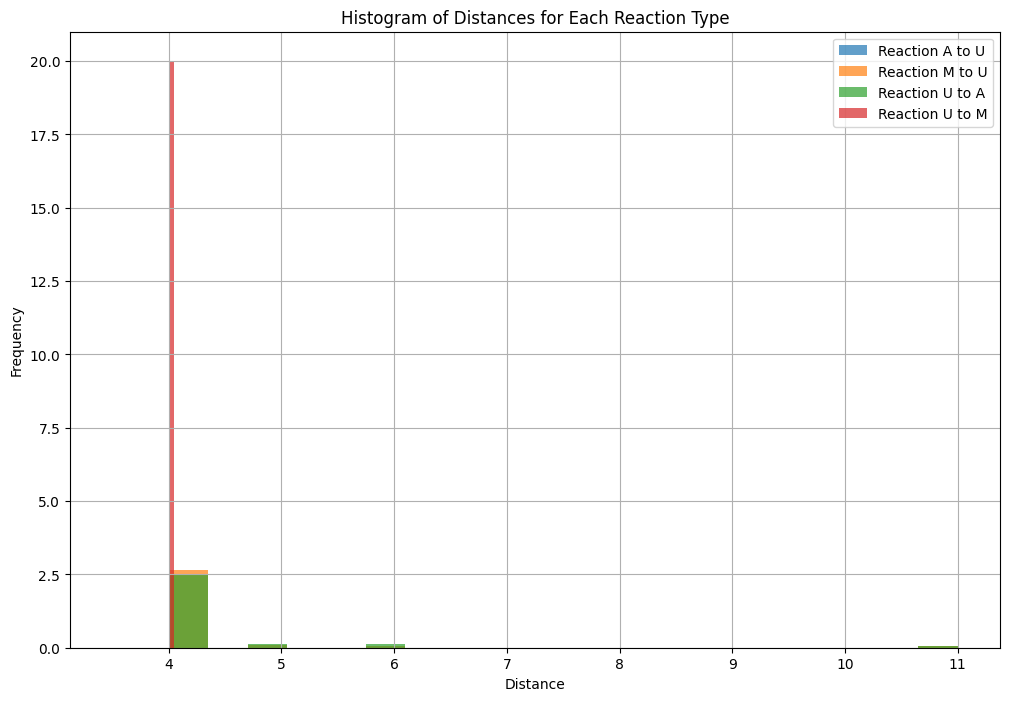

Reaction A to U count: 0
Reaction M to U count: 58
Reaction U to A count: 44
Reaction U to M count: 11


In [ ]:
import re
import matplotlib.pyplot as plt

# Define the path to your log file
log_file_path = 'output.log'

# Initialize dictionaries to store counts and distances for each type of reaction
reaction_counts = {'f1': 0, 'f2': 0, 'f3': 0, 'f4': 0}
reaction_distances = {'f1': set(), 'f2': set(), 'f3': set(), 'f4': set()}

# Define a mapping from log reaction types to our reaction types
reaction_map = {'reacAU': 'f1', 'reacMU': 'f2', 'reacUA': 'f3', 'reacUM': 'f4'}

# Define a regex pattern to match lines containing reacting atom IDs and reaction types
pattern = re.compile(r'reacted_atom_IDs: (reac\w+) (\d+) (\d+)')

# Open the log file and read its contents
with open(log_file_path, 'r') as file:
    lines = file.readlines()

# Loop through each line and search for the pattern
for line in lines:
    match = pattern.search(line)
    if match:
        # Extract the reaction type and atom IDs
        reaction_type = match.group(1)
        atom_id_1 = int(match.group(2))
        atom_id_2 = int(match.group(3))
        
        # Calculate distance
        distance = abs(atom_id_1 - atom_id_2)
        
        # Get the corresponding reaction type from the map
        reaction_key = reaction_map[reaction_type]
        
        # Add the reaction event to the set of unique events
        reaction_distances[reaction_key].add((reaction_type, atom_id_1, atom_id_2))
        
        # Increment the count for the corresponding reaction type
        reaction_counts[reaction_key] += 1

labels = {'f1': 'Reaction A to U', 'f2': 'Reaction M to U', 'f3': 'Reaction U to A', 'f4': 'Reaction U to M'}

# Plot histograms of distances for each reaction type
plt.figure(figsize=(12, 8))
for reaction_type, distances in reaction_distances.items():
    plt.hist([abs(id1 - id2) for _, id1, id2 in distances], bins=20, alpha=0.7, label=f'{labels[reaction_type]}', density=True)

plt.title('Histogram of Distances for Each Reaction Type')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Print the counts of each reaction type
for reaction_type, count in reaction_counts.items():
    print(f'{labels[reaction_type]} count: {count}')


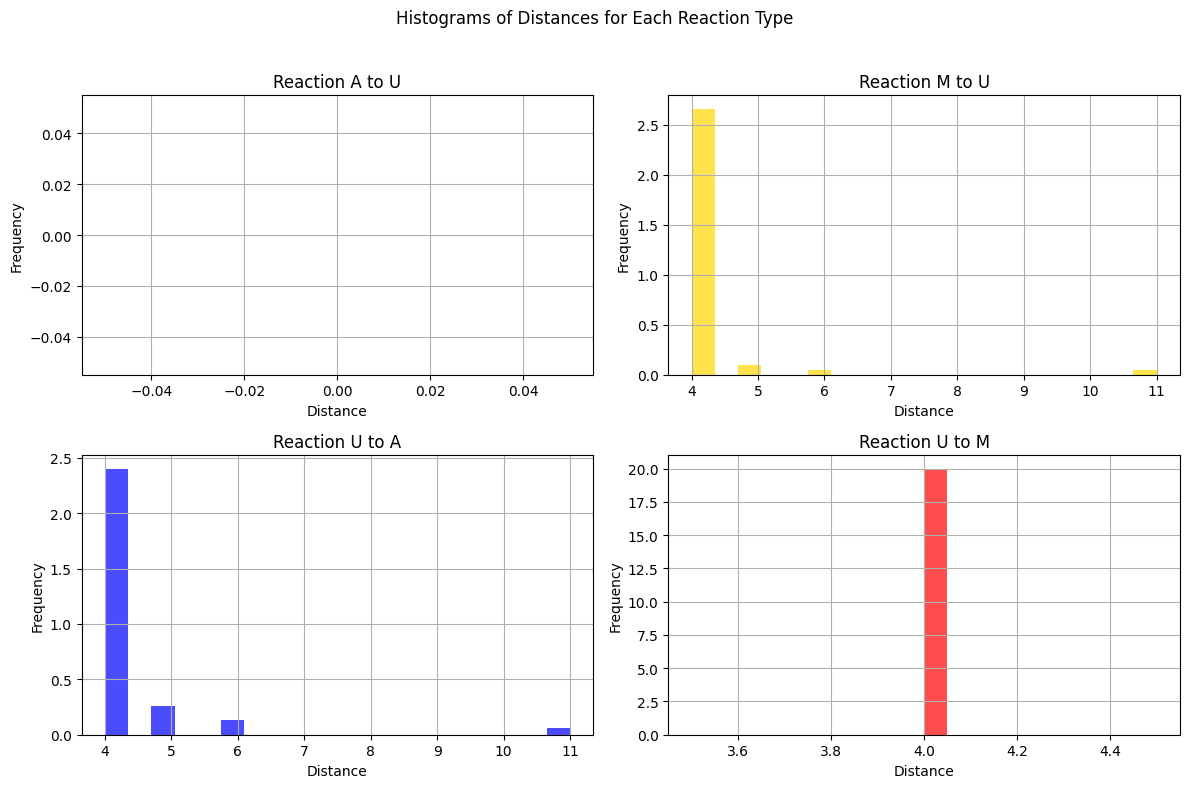

Reaction A to U count: 0
Reaction M to U count: 58
Reaction U to A count: 44
Reaction U to M count: 11


In [ ]:
import re
import matplotlib.pyplot as plt

# Define the path to your log file
log_file_path = 'output.log'

# Initialize dictionaries to store counts and distances for each type of reaction
reaction_counts = {'f1': 0, 'f2': 0, 'f3': 0, 'f4': 0}
reaction_distances = {'f1': [], 'f2': [], 'f3': [], 'f4': []}

# Define a mapping from log reaction types to our reaction types
reaction_map = {'reacAU': 'f1', 'reacMU': 'f2', 'reacUA': 'f3', 'reacUM': 'f4'}

# Define a regex pattern to match lines containing reacting atom IDs and reaction types
pattern = re.compile(r'reacted_atom_IDs: (reac\w+) (\d+) (\d+)')

# Open the log file and read its contents
with open(log_file_path, 'r') as file:
    lines = file.readlines()

# Loop through each line and search for the pattern
for line in lines:
    match = pattern.search(line)
    if match:
        # Extract the reaction type and atom IDs
        reaction_type = match.group(1)
        atom_id_1 = int(match.group(2))
        atom_id_2 = int(match.group(3))
        
        # Calculate distance
        distance = abs(atom_id_1 - atom_id_2)
        
        # Get the corresponding reaction type from the map
        reaction_key = reaction_map[reaction_type]
        
        # Add the reaction event to the list of distances
        reaction_distances[reaction_key].append(distance)
        
        # Increment the count for the corresponding reaction type
        reaction_counts[reaction_key] += 1

labels = {'f1': 'Reaction A to U', 'f2': 'Reaction M to U', 'f3': 'Reaction U to A', 'f4': 'Reaction U to M'}
colors = {'f1': 'yellow', 'f2': 'gold', 'f3': 'blue', 'f4': 'red'}

# Plot histograms of distances for each reaction type in subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms of Distances for Each Reaction Type')

for ax, (reaction_type, distances) in zip(axs.flatten(), reaction_distances.items()):
    ax.hist(distances, bins=20, alpha=0.7, density=True, color=colors[reaction_type])
    ax.set_title(labels[reaction_type])
    ax.set_xlabel('Distance')
    ax.set_ylabel('Frequency')
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print the counts of each reaction type
for reaction_type, count in reaction_counts.items():
    print(f'{labels[reaction_type]} count: {count}')


In [19]:
import re
import matplotlib.pyplot as plt

# Define the path to your log file
log_file_path = 'output.log'

# Initialize dictionaries to store counts and distances for each type of reaction
reaction_counts = {'f1': 0, 'f2': 0, 'f3': 0, 'f4': 0}
reaction_distances = {'f1': [], 'f2': [], 'f3': [], 'f4': []}

# Define a mapping from log reaction types to our reaction types
reaction_map = {'reacAU': 'f1', 'reacMU': 'f2', 'reacUA': 'f3', 'reacUM': 'f4'}

# Define a regex pattern to match lines containing reacting atom IDs and reaction types
pattern = re.compile(r'reacted_atom_IDs: (reac\w+) (\d+) (\d+)')

# Open the log file and read its contents
with open(log_file_path, 'r') as file:
    lines = file.readlines()

# Loop through each line and search for the pattern
for line in lines:
    match = pattern.search(line)
    if match:
        # Extract the reaction type and atom IDs
        reaction_type = match.group(1)
        atom_id_1 = int(match.group(2))
        atom_id_2 = int(match.group(3))
        
        # Calculate distance
        distance = abs(atom_id_1 - atom_id_2)
        
        # Get the corresponding reaction type from the map
        reaction_key = reaction_map[reaction_type]
        
        # Add the reaction event to the list of distances
        reaction_distances[reaction_key].append(distance)
        
        # Increment the count for the corresponding reaction type
        reaction_counts[reaction_key] += 1

labels = {'f1': 'Reaction A to U', 'f2': 'Reaction M to U', 'f3': 'Reaction U to A', 'f4': 'Reaction U to M'}
colors = {'f1': 'yellow', 'f2': 'gold', 'f3': 'blue', 'f4': 'red'}

# Plot histograms of distances for each reaction type in subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histograms of Distances for Each Reaction Type')

for ax, (reaction_type, distances) in zip(axs.flatten(), reaction_distances.items()):
    ax.hist(distances, bins=20, alpha=0.7, density=True, color=colors[reaction_type])
    ax.set_title(labels[reaction_type])
    ax.set_xlabel('Distance')
    ax.set_ylabel('Frequency')
    ax.grid(True)
    ax.set_yscale('log')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print the counts of each reaction type
for reaction_type, count in reaction_counts.items():
    print(f'{labels[reaction_type]} count: {count}')


KeyError: 'reacSwi6toSwi6M'

In [ ]:
A = np.linspace(50,5000,50)

In [ ]:
for j in A:
    print(int(j),end = " ")

50 151 252 353 454 555 656 757 858 959 1060 1161 1262 1363 1464 1565 1666 1767 1868 1969 2070 2171 2272 2373 2474 2575 2676 2777 2878 2979 3080 3181 3282 3383 3484 3585 3686 3787 3888 3989 4090 4191 4292 4393 4494 4595 4696 4797 4898 5000 